In [1]:
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch as T

X, y = load_boston(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = T.as_tensor(X_train).type(T.float32)
X_test = T.as_tensor(X_test).type(T.float32)

In [2]:
from chemvae import ChemVAE, elbo_loss

vae = ChemVAE(X_train.shape[1], 32)
vae.train()
opt = T.optim.Adam(vae.parameters(), lr=0.01)

for ep in range(40):

    opt.zero_grad()
    recon_x, mean, logvar = vae(X_train)
    loss_val = elbo_loss(recon_x, X_train, mean, logvar, 2.0)
    loss_val.backward()
    epoch_loss = loss_val.item()
    opt.step()

    if ep % 5 == 0:
        print(f'{ep} | {epoch_loss}')

0 | 10439.779296875
5 | 8616.8408203125
10 | 7108.6123046875
15 | 5818.7412109375
20 | 4818.63037109375
25 | 4156.75537109375
30 | 3749.02587890625
35 | 3528.5517578125


In [3]:
test_recon_x, test_mean, test_logvar = vae(X_test)
test_loss_val = elbo_loss(test_recon_x, X_test, test_mean, test_logvar, 1.0).item()
print(test_loss_val)
print()
print(X_test[0])
print()
print(test_recon_x[0])

367.6284484863281

tensor([4.3048e-04, 2.5000e-01, 1.5259e-01, 0.0000e+00, 8.4362e-02, 5.8594e-01,
        6.9516e-01, 3.8839e-01, 1.3043e-01, 1.7939e-01, 6.8085e-01, 9.9678e-01,
        1.5149e-01])

tensor([0.1155, 0.1371, 0.3855, 0.1561, 0.3510, 0.4998, 0.6482, 0.2269, 0.3863,
        0.4328, 0.6508, 0.8629, 0.2503], grad_fn=<SelectBackward>)


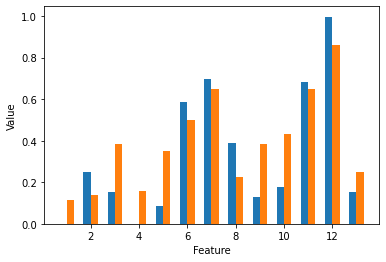

In [4]:
from matplotlib import pyplot as plt

plt.clf()
plt.bar([i + 0.85 for i in range(len(X_test[0]))], X_test[0], 0.3)
plt.bar([i + 1.15 for i in range(len(test_recon_x[0]))], test_recon_x[0].detach().numpy(), 0.3)
plt.xlabel('Feature')
plt.ylabel('Value')
plt.show()